In [1]:
import os

# Subir un nivel respecto a la carpeta actual
os.chdir("..")

import numpy as np
from globals import SAMPLE_RATE
import librosa
import matplotlib.pyplot as plt
from IPython.display import Audio, display

from Utils import from_matrix_to_preset, denormalize_preset, pretty_print, get_audio, split_audio
import numpy as np
import matplotlib.pyplot as plt
from Optimizers import search_with_DE, search_with_CMA, evaluate_target, render_presets

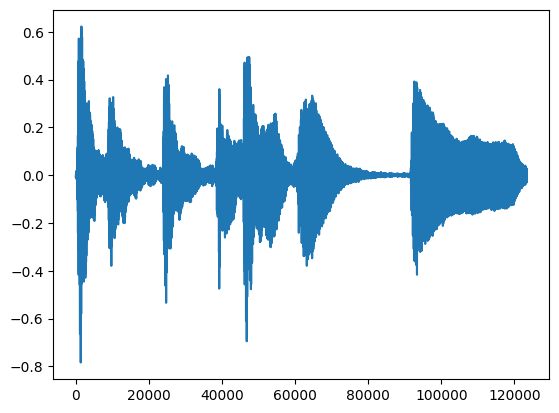

In [2]:
audio_path = 'C:/Users/bryan/Documents/GitHub/Synth/presets/MarioPiano.mp3'
audio = get_audio(audio_path)

plt.plot(audio)
plt.show()
Audio(audio, rate=SAMPLE_RATE)

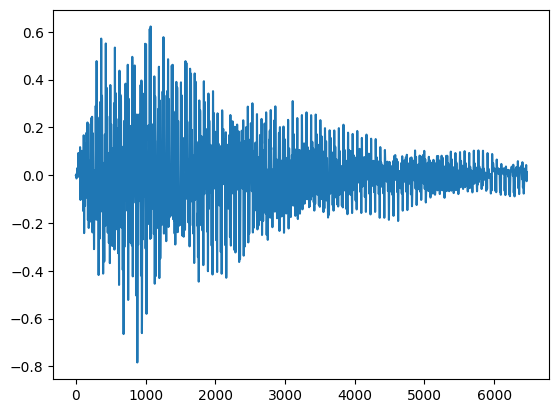

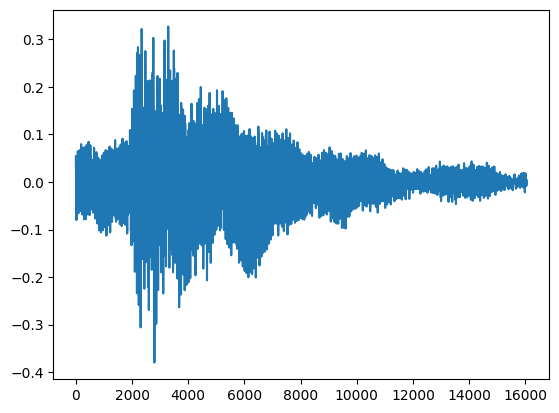

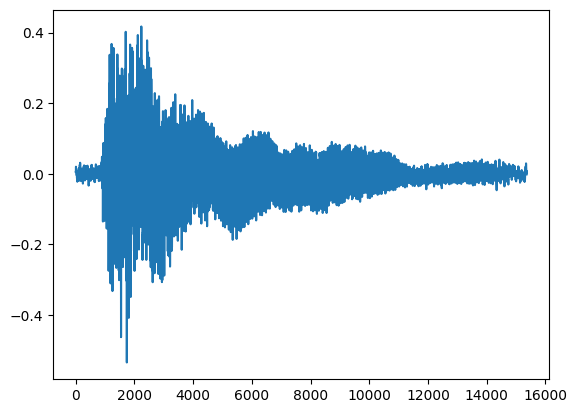

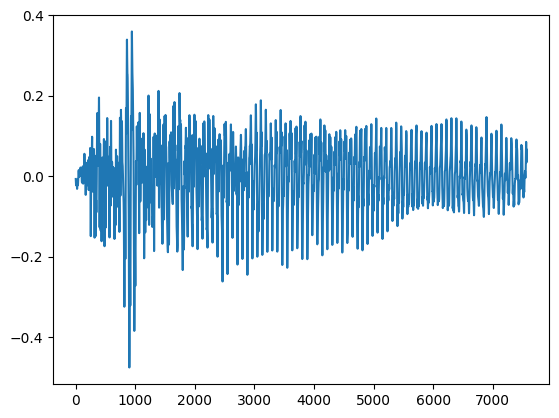

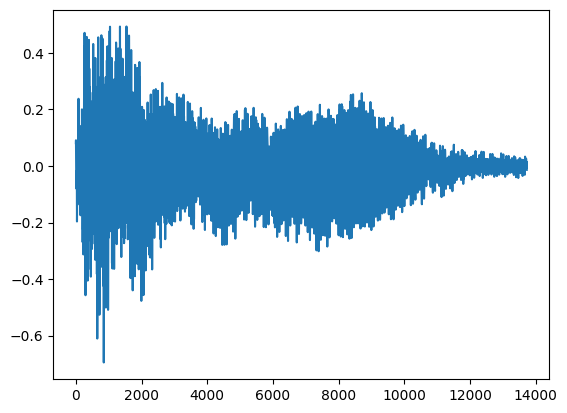

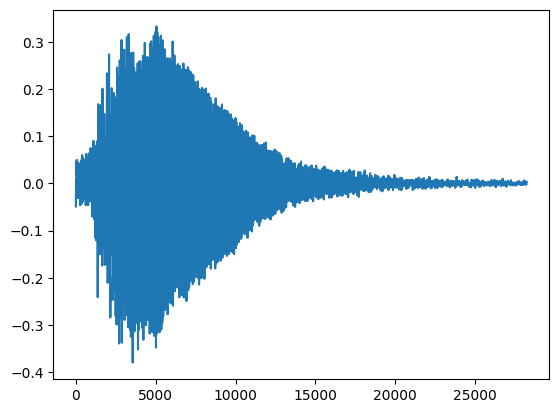

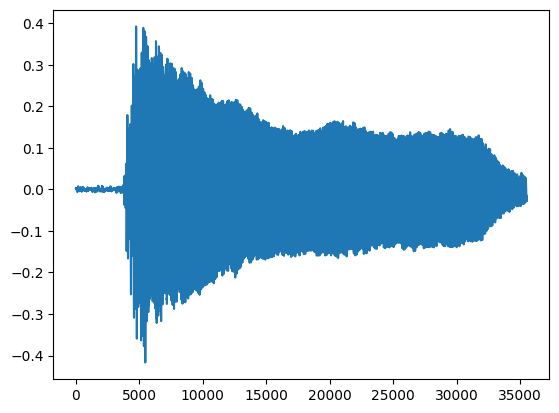

Pieces 7


In [3]:
audio_segments = split_audio(audio, prominence=0.05)

for audio_segment in audio_segments:
    plt.plot(audio_segment)
    plt.show()
    display(Audio(audio_segment, rate=SAMPLE_RATE))

print('Pieces', len(audio_segments))

In [4]:
estimated_presets = []
i = 1
last_best = None

if __name__ == '__main__':
    for audio_segment in audio_segments:
        print('Piece', i)
        target_C = evaluate_target(np.expand_dims(audio_segment, axis=0))
        duration = len(audio_segment) / SAMPLE_RATE
        if last_best is None:
            best = search_with_DE(target_C, duration, disp=False, maxiter=200)
            best = search_with_CMA(target_C, duration, best, tolfun=1e-4, tolx=1e-4, tolfunhist=1e-4)
        else:
            best = search_with_CMA(target_C, duration, last_best, tolfun=1e-4, tolx=1e-4, tolfunhist=1e-4)

        last_best = best
        estimated_presets.append((best, duration))
        i+=1

Piece 1


c:\Users\bryan\Documents\GitHub\Synth\venv\Lib\site-packages\scipy\optimize\_differentialevolution.py:487: UserWarning: differential_evolution: the 'vectorized' keyword has overridden updating='immediate' to updating='deferred'
  with DifferentialEvolutionSolver(func, bounds, args=args,


(15_w,30)-aCMA-ES (mu_w=8.6,w_1=20%) in dimension 29 (seed=266264, Wed Feb  4 19:30:52 2026)
(15_w,30)-aCMA-ES (mu_w=8.6,w_1=20%) in dimension 29 (seed=417268, Wed Feb  4 19:32:14 2026)
(15_w,30)-aCMA-ES (mu_w=8.6,w_1=20%) in dimension 29 (seed=379089, Wed Feb  4 19:32:56 2026)
Piece 2
(15_w,30)-aCMA-ES (mu_w=8.6,w_1=20%) in dimension 29 (seed=291999, Wed Feb  4 19:33:43 2026)
(15_w,30)-aCMA-ES (mu_w=8.6,w_1=20%) in dimension 29 (seed=348114, Wed Feb  4 19:34:24 2026)
(15_w,30)-aCMA-ES (mu_w=8.6,w_1=20%) in dimension 29 (seed=365540, Wed Feb  4 19:35:20 2026)
Piece 3
(15_w,30)-aCMA-ES (mu_w=8.6,w_1=20%) in dimension 29 (seed=368005, Wed Feb  4 19:36:31 2026)
(15_w,30)-aCMA-ES (mu_w=8.6,w_1=20%) in dimension 29 (seed=356092, Wed Feb  4 19:38:03 2026)
(15_w,30)-aCMA-ES (mu_w=8.6,w_1=20%) in dimension 29 (seed=319531, Wed Feb  4 19:39:21 2026)
Piece 4
(15_w,30)-aCMA-ES (mu_w=8.6,w_1=20%) in dimension 29 (seed=356441, Wed Feb  4 19:40:00 2026)
(15_w,30)-aCMA-ES (mu_w=8.6,w_1=20%) in dimens

In [5]:
predicted_joined_audio = []

for preset, duration in estimated_presets:
    preset = np.expand_dims(preset, axis=0)
    # error = evaluate_presets((denormalize_preset(from_matrix_to_preset(preset)), target_C, duration))
    # print('Error', error)
    # target_audio = np.expand_dims(audio_segments[0], axis=0)
    predicted_audio = render_presets(denormalize_preset(from_matrix_to_preset(preset)), duration)
    predicted_joined_audio.append(predicted_audio[0])

    denormalized_predicted_preset = denormalize_preset(from_matrix_to_preset(preset))
    pretty_print(denormalized_predicted_preset)

predicted_joined_audio = np.concatenate(predicted_joined_audio, axis=0)

{
  osc1_shape:   [
    2.495188250635497
  ]
  osc1_phase:   [
    0.7103963200045686
  ]
  osc1_volume:   [
    0.3416909994162798
  ]
  osc1_freq:   [
    35.703272255569225
  ]
  osc2_shape:   [
    0.8348141436323998
  ]
  osc2_phase:   [
    0.31532774049540985
  ]
  osc2_volume:   [
    0.9599229337781912
  ]
  osc2_freq:   [
    21842.228567098824
  ]
  osc3_shape:   [
    0.13145502622153896
  ]
  osc3_phase:   [
    0.6816864210464284
  ]
  osc3_volume:   [
    0.2793494759801999
  ]
  osc3_freq:   [
    2665.1964983748007
  ]
  osc4_shape:   [
    1.1599296053636283
  ]
  osc4_phase:   [
    0.15780447150959195
  ]
  osc4_volume:   [
    0.6962546009567451
  ]
  osc4_freq:   [
    665.9429105302934
  ]
  oscnoise_volume:   [
    0.00022681126084299173
  ]
  filter_envelope_attack:   [
    0.3572792452962917
  ]
  filter_envelope_decay:   [
    0.022596655431964742
  ]
  filter_envelope_sustain:   [
    0.671734908575794
  ]
  filter_envelope_release:   [
    0.19515338046752

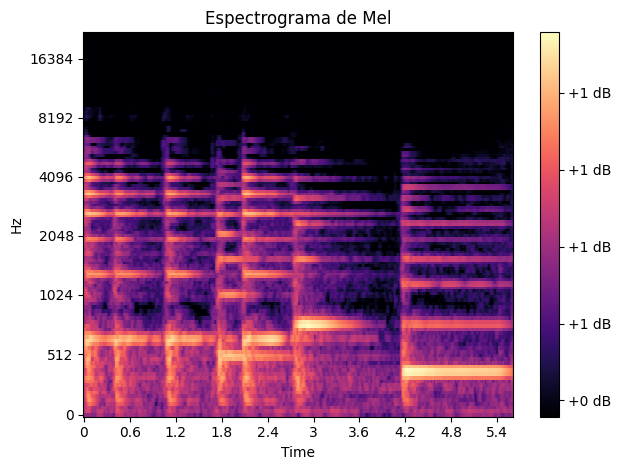

In [6]:
spect = evaluate_target(np.array([audio]))[0]
librosa.display.specshow(spect, sr=SAMPLE_RATE, x_axis='time', y_axis='mel')
plt.colorbar(format='%+2.0f dB')
plt.title('Espectrograma de Mel')
plt.tight_layout()
plt.show()

display(Audio(audio, rate=SAMPLE_RATE))

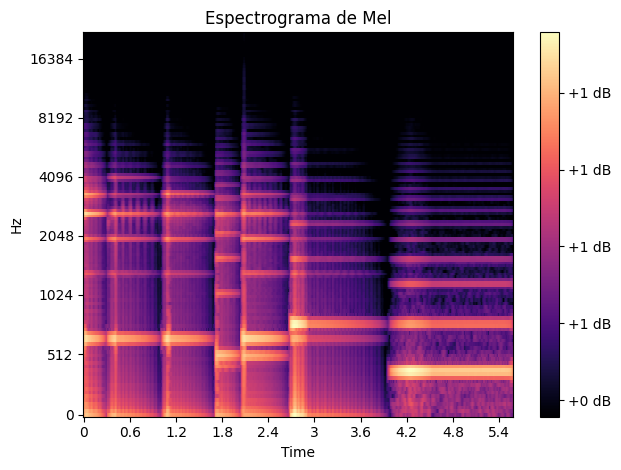

In [7]:
spect = evaluate_target(np.array([predicted_joined_audio]))[0]
librosa.display.specshow(spect, sr=SAMPLE_RATE, x_axis='time', y_axis='mel')
plt.colorbar(format='%+2.0f dB')
plt.title('Espectrograma de Mel')
plt.tight_layout()
plt.show()

display(Audio(predicted_joined_audio, rate=SAMPLE_RATE))